# Lunar Lander - Reinforce Learning & Deep Q

In [39]:
import time
from collections import deque, namedtuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import gymnasium as gym
import numpy as np
from typing import Tuple
from PIL import Image
import utils

import random
random.seed(9)

# Set up a virtual display to render the Lunar Lander environment.
import os
from pyvirtualdisplay import Display

os.environ['DISPLAY'] = ':99' 
disp = Display(visible=0, size=(840, 480), backend="xvfb")
disp.start()

# os.environ['DISPLAY'] = 'localhost:98' 
# env = gym.make("LunarLander-v3", render_mode="rgb_array")
# state, _ = env.reset()
# print("🎉 终于成功了！状态向量：", state)

In [18]:
MEMORY_SIZE = 100_000     # size of memory buffer
GAMMA = 0.995             # discount factor
ALPHA = 1e-3              # learning rate  
NUM_STEPS_FOR_UPDATE = 4  # perform a learning update every C time steps

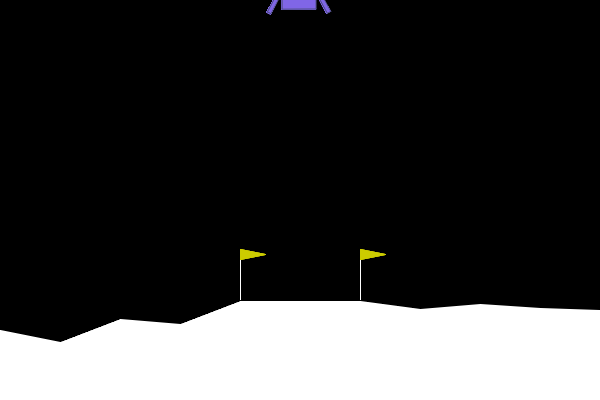

In [20]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env.reset()
img_array = env.render()
img = Image.fromarray(img_array)
img

In [24]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)
print(f'env.observation_space: {env.observation_space}')
print(f'env.action_space: {env.action_space}')

State Shape: (8,)
Number of actions: 4
env.observation_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
env.action_space: Discrete(4)


In [36]:
initial_state = env.reset()

# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
next_state, reward, done, truncated, info = env.step(action)

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("Initial State:", initial_state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward Received:", reward)
    print("Episode Terminated:", done)
    print("Truncated:", truncated)
    print("Info:", info)

Initial State: (array([-0.002, 1.422, -0.252, 0.507, 0.003, 0.057, 0.000, 0.000],
      dtype=float32), {})
Action: 0
Next State: [-0.005 1.433 -0.252 0.482 0.006 0.057 0.000 0.000]
Reward Received: 0.9399766586739418
Episode Terminated: False
Truncated: False
Info: {}


In [ ]:
class LunarLanderModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()  # 必须写
        self.lander_nn = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, states) -> Tensor:
        v = self.lander_nn(states)
        
        return v

In [41]:
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

In [ ]:
# V1
def compute_loss_v1(experiences: Tuple, gamma: float, q_model, target_model) -> Tensor:
    
    states, actions, rewards, next_states, done_vals = experiences

    target_tensor = target_model(torch.as_tensor(next_states, dtype=torch.float32))
    print(f"target_tensor type: {type(target_tensor)}")
    target_max, _ = torch.max(target_tensor, dim=-1)

    y_targets = rewards + (gamma * target_max * (1 - done_vals))

    q_tensor = q_model(torch.tensor(states, dtype=torch.float32))
    q_values = q_tensor.gather(dim=1, index=actions.unsqueeze(1))

    # 计算损失
    loss = F.mse_loss(y_targets, q_values)
    
    return loss

def compute_loss_v2(experiences, gamma, q_model, target_model) -> torch.Tensor:
    states, actions, rewards, next_states, done_vals = experiences
    
    # 转换所有输入为 Tensor
    states = torch.tensor(states, dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.long)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(next_states, dtype=torch.float32)
    done_vals = torch.tensor(done_vals, dtype=torch.float32)

    # 1. 计算目标值 (Target Q) - 不计梯度
    with torch.no_grad():
        target_tensor = target_model(next_states)
        target_max, _ = torch.max(target_tensor, dim=-1)
        # y_targets 形状: [64]
        y_targets = rewards + (gamma * target_max * (1 - done_vals))

    # 2. 计算当前预测值 (Current Q)
    q_tensor = q_model(states)
    # q_values 形状: [64, 1]
    q_values = q_tensor.gather(dim=1, index=actions.unsqueeze(1))

    # 3. 计算损失 (注意对齐 y_targets 的维度)
    # 将 y_targets 从 [64] 变成 [64, 1]
    loss = F.mse_loss(q_values, y_targets.unsqueeze(1))
    
    return loss

def test_compute_loss(target):
    num_actions = 4
    input_dim = 8
    def target_q_network_random(inputs):
        return LunarLanderModel(input_dim, num_actions)
    
    def q_network_random(inputs):
        return LunarLanderModel(input_dim, num_actions)
    
    def target_q_network_ones(inputs):
        return LunarLanderModel(input_dim, num_actions)
    
    def q_network_ones(inputs):
        return LunarLanderModel(input_dim, num_actions)
    
    np.random.seed(1)
    states = np.float32(np.random.rand(64, 8))
    actions = np.float32(np.floor(np.random.uniform(0, 1, (64, )) * 4))
    rewards = np.float32(np.random.rand(64, ))
    next_states = np.float32(np.random.rand(64, 8))
    done_vals = np.float32((np.random.uniform(0, 1, size=(64,)) > 0.96) * 1)

    loss = target((states, actions, rewards, next_states, done_vals), 0.995, q_network_random, target_q_network_random)
    

    assert np.isclose(loss, 0.6991737), f"Wrong value. Expected {0.6991737}, got {loss}"

    # Test when episode terminates
    done_vals = np.float32(np.ones((64,)))
    loss = target((states, actions, rewards, next_states, done_vals), 0.995, q_network_ones, target_q_network_ones)
    assert np.isclose(loss, 0.343270182), f"Wrong value. Expected {0.343270182}, got {loss}"
      
    # Test MSE with parameters A = B
    done_vals = np.float32((np.random.uniform(0, 1, size=(64,)) > 0.96) * 1)
    rewards = np.float32(np.ones((64, )))
    loss = target((states, actions, rewards, next_states, done_vals), 0, q_network_ones, target_q_network_ones)
    assert np.isclose(loss, 0), f"Wrong value. Expected {0}, got {loss}"
 
    # Test MSE with parameters A = 0 and B = 1
    done_vals = np.float32((np.random.uniform(0, 1, size=(64,)) > 0.96) * 1)
    rewards = np.float32(np.zeros((64, )))
    loss = target((states, actions, rewards, next_states, done_vals), 0, q_network_ones, target_q_network_ones)
    assert np.isclose(loss, 1), f"Wrong value. Expected {1}, got {loss}"

    print("\033[92mAll tests passed!")

test_compute_loss(compute_loss)

target_tensor type: <class '__main__.LunarLanderModel'>


TypeError: max() received an invalid combination of arguments - got (LunarLanderModel, dim=int), but expected one of:
 * (Tensor input, *, Tensor out = None)
 * (Tensor input, Tensor other, *, Tensor out = None)
 * (Tensor input, int dim, bool keepdim = False, *, tuple of Tensors out = None)
 * (Tensor input, name dim, bool keepdim = False, *, tuple of Tensors out = None)


In [ ]:
q_model = LunarLanderModel(input_dim=8, output_dim=4)
q_model.train()
target_model = LunarLanderModel(input_dim=8, output_dim=4)
target_model.train()
criterion = nn.MSELoss()
ALPHA = 1e-2
optimizer = optim.Adam(q_model.parameters(), ALPHA)
